# PosEnc Output Comparison

This notebook has two modes:

- **Saved-output summary** from `out/encoded_*.npy` (optional).
- **Canonical probe diagnostics** using fixed demo settings (`seq_len=64`, `dim=64`) so RoPE-style plots match the original interpretation.

Probe diagnostics are computed from encoder implementations directly (not from random saved vectors).
            


In [164]:
from pathlib import Path
import json
import sys

import numpy as np

try:
    import matplotlib.pyplot as plt
    HAVE_MPL = True
except Exception as exc:
    HAVE_MPL = False
    print('matplotlib unavailable:', exc)
    print('Install notebook deps with: uv sync --extra notebooks')
            


In [165]:
REPO_CANDIDATES = [
    Path.cwd(),
    Path.cwd().parent,
    Path('/home/jake/Developer/posenc'),
]

REPO_ROOT = next(
    (
        p.resolve()
        for p in REPO_CANDIDATES
        if (p / 'core' / 'types.py').exists() and (p / 'encoders' / '__init__.py').exists()
    ),
    Path('/home/jake/Developer/posenc').resolve(),
)

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print('REPO_ROOT:', REPO_ROOT)

RUN_DIR_CANDIDATES = [
    REPO_ROOT / 'out',
    Path('out').resolve(),
    Path('../out').resolve(),
]
RUN_DIR = next((p for p in RUN_DIR_CANDIDATES if p.exists()), RUN_DIR_CANDIDATES[0])
print('RUN_DIR:', RUN_DIR)


def load_artifacts(run_dir: Path):
    meta_path = run_dir / 'metadata.json'
    vectors_path = run_dir / 'vectors.npy'
    if not meta_path.exists() or not vectors_path.exists():
        raise FileNotFoundError(
            f'Missing artifacts in {run_dir}. Expected metadata.json and vectors.npy.'
        )

    metadata = json.loads(meta_path.read_text())
    vectors = np.load(vectors_path)
    encoded = {
        p.stem.replace('encoded_', ''): np.load(p)
        for p in sorted(run_dir.glob('encoded_*.npy'))
    }
    return metadata, vectors, encoded


try:
    metadata, vectors, encoded = load_artifacts(RUN_DIR)
    print('encoders with saved tensors:', list(encoded.keys()))
    print('saved vectors shape:', vectors.shape)
except FileNotFoundError as exc:
    print(exc)
    print('Generate artifacts with:')
    print('uv run python main.py --encoders all --save-dir out --save-encoded')
    metadata = None
    vectors = None
    encoded = {}
            


REPO_ROOT: /home/jake/Developer/posenc
RUN_DIR: /home/jake/Developer/posenc/out
encoders with saved tensors: ['ape', 'axial', 'f-monster', 'monster', 'rope', 'spiral']
saved vectors shape: (1, 768)


In [166]:
from core.positions import build_position_bank, parse_coords, parse_t_values
from core.types import PositionBank, RunConfig
from encoders import encoder_names, resolve_specs

DEMO_PROBE_SEQ_LEN = 2 ** 10
DEMO_ATTN_SEQ_LEN = 64
DEMO_DIM = 96
DEMO_THETA_BASE = 10000.0
DEMO_SEED = 0
DEMO_COORDS = 't'
DEMO_T_VALUES = np.arange(DEMO_PROBE_SEQ_LEN, dtype=np.float64)
DEMO_MONSTER_SPAN = 2.0 * np.pi
DEMO_MONSTER_TOP_DELTA = 256.0
DEMO_MONSTER_UNIT = DEMO_MONSTER_SPAN / DEMO_MONSTER_TOP_DELTA
DEMO_MONSTER_PHI_MAX = (DEMO_PROBE_SEQ_LEN - 1) * DEMO_MONSTER_UNIT
DEMO_MONSTER_TIME_SCALE = 0.005

requested_names = list(metadata.get('encoders', [])) if metadata else []
if not requested_names:
    requested_names = list(encoder_names())

# Keep order stable and remove duplicates.
seen = set()
requested_names = [name for name in requested_names if not (name in seen or seen.add(name))]
requested_names = [name for name in requested_names if name != 'ape']

probe_contexts = {}
skipped = {}

for name in requested_names:
    per_encoder_params = {}
    if name == 'spiral':
        per_encoder_params = {'num_directions': 1}
    if name in {'monster', 'f-monster'}:
        per_encoder_params = {
            'span': DEMO_MONSTER_SPAN,
            'top_delta': DEMO_MONSTER_TOP_DELTA,
        }

    cfg = RunConfig(
        encoders=(name,),
        dim=DEMO_DIM,
        num_vectors=2,
        seed=DEMO_SEED,
        theta_base=DEMO_THETA_BASE,
        coords_spec=parse_coords(DEMO_COORDS),
        grid_size=1,
        centered_coords=False,
        t_values=parse_t_values(DEMO_T_VALUES.tolist()),
        z_value=0.0,
        position_chunk_size=DEMO_PROBE_SEQ_LEN,
        save_dir=None,
        save_encoded=False,
        encoder_params={name: per_encoder_params} if per_encoder_params else {},
    )

    spec = resolve_specs([name])[0]
    check = spec.validate_config(cfg)
    if not check.ok:
        skipped[name] = check.rule
        continue

    bank = build_position_bank(
        cfg.coords_spec,
        cfg.grid_size,
        cfg.centered_coords,
        cfg.t_values,
        cfg.z_value,
    )
    if name in {'monster', 'f-monster'}:
        s = np.arange(DEMO_PROBE_SEQ_LEN, dtype=np.float64)
        t = DEMO_MONSTER_TIME_SCALE * s
        pos4 = np.stack((t, s, s, s), axis=1)
        bank = PositionBank(rope_positions=bank.rope_positions, positions_4d=pos4)
    cache = spec.precompute(cfg, bank)

    probe_contexts[name] = {
        'cfg': cfg,
        'spec': spec,
        'bank': bank,
        'cache': cache,
    }

print('probe-enabled encoders:', list(probe_contexts.keys()))
print(f'DEMO lengths: probe_seq={DEMO_PROBE_SEQ_LEN}, attn_seq={DEMO_ATTN_SEQ_LEN}')
print(f'DEMO monster/f-monster: span={DEMO_MONSTER_SPAN}, top_delta={DEMO_MONSTER_TOP_DELTA}, unit={DEMO_MONSTER_UNIT:.6f}, phi_max~{DEMO_MONSTER_PHI_MAX:.6f}')
print(f'DEMO monster/f-monster probe path: t={DEMO_MONSTER_TIME_SCALE}*s, x=y=z=s, s=0..{DEMO_PROBE_SEQ_LEN - 1}')
if skipped:
    print(f'skipped encoders (incompatible with demo dim={DEMO_DIM}):')
    for name, rule in skipped.items():
        print(f'  - {name}: {rule}')



probe-enabled encoders: ['rope', 'axial', 'spiral', 'monster', 'f-monster']
DEMO monster/f-monster: span=6.283185307179586, top_delta=256.0, unit=0.024544, phi_max~1.546253
DEMO monster/f-monster position path: t=0.005*s, x=y=z=s, s=0..63


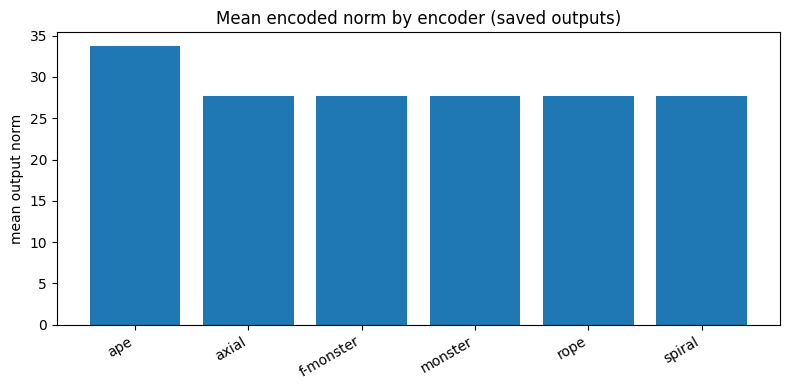

In [167]:
if not encoded:
    print('No saved encoded tensors loaded; skipping saved-output norm summary.')
else:
    mean_norm_by_encoder = {}
    for name, tensor in encoded.items():
        norms = np.linalg.norm(tensor, axis=2)
        mean_norm_by_encoder[name] = float(np.mean(norms))

    if HAVE_MPL:
        plt.figure(figsize=(8, 4))
        plt.bar(mean_norm_by_encoder.keys(), mean_norm_by_encoder.values())
        plt.ylabel('mean output norm')
        plt.title('Mean encoded norm by encoder (saved outputs)')
        plt.xticks(rotation=30, ha='right')
        plt.tight_layout()
        plt.show()
    else:
        for name, value in mean_norm_by_encoder.items():
            print(f'{name}: {value:.6f}')
            


Probe heatmap setup:
  monster/f-monster path (suppressed): t=0.005*s, x=y=z=s
  monster/f-monster path (unsuppressed): t=s, x=y=z=s
  monster channels are axis-aligned local readouts [t, axis, u, v] per sub-block
  f-monster channels are axis-aligned local readouts [t, axis, b, c] per block
RoPE-family shared range: [-1.000000, 1.000000]
rope probe sanity corr vs canonical dim=96: 1.000000


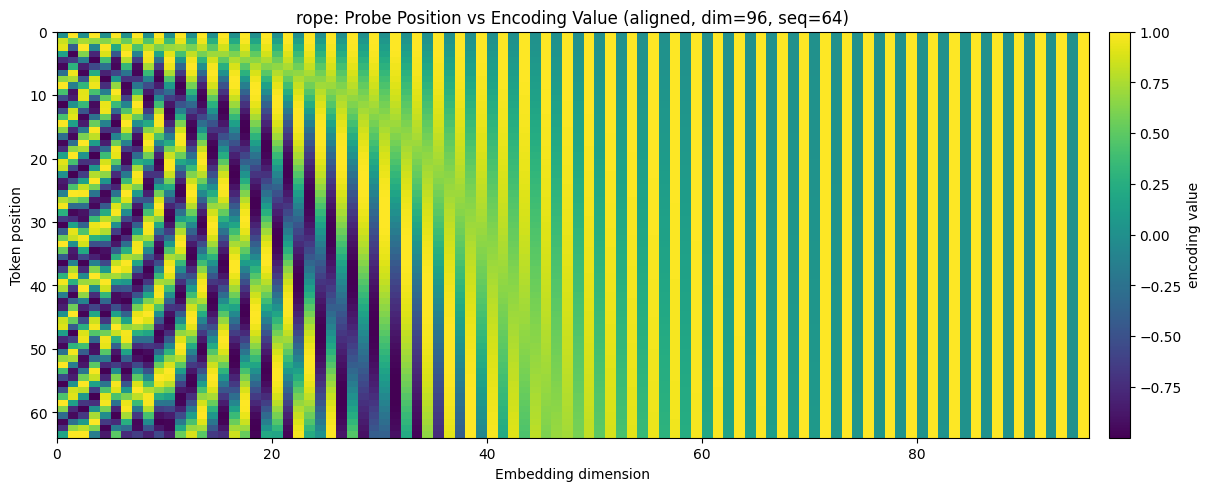

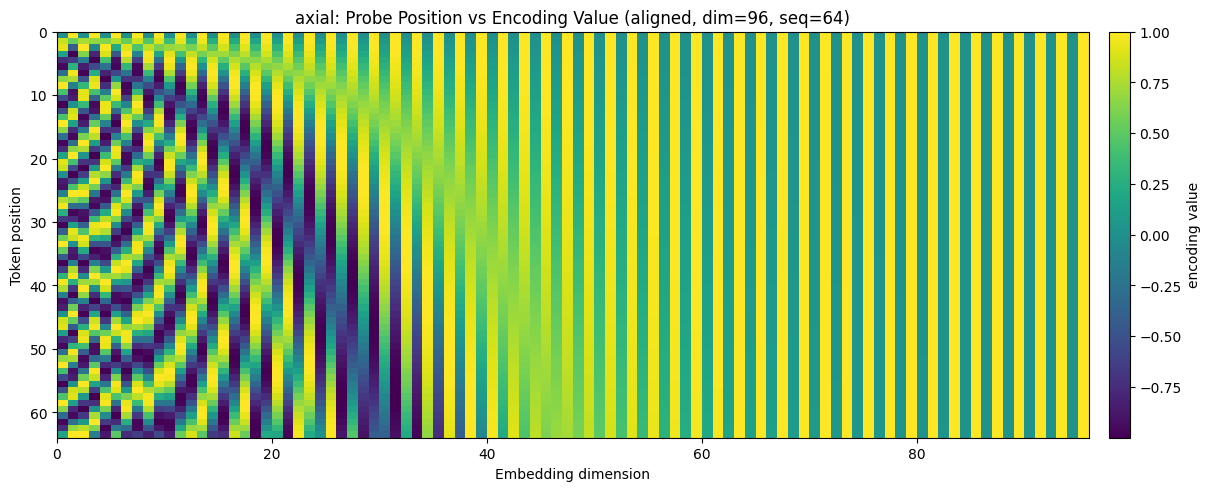

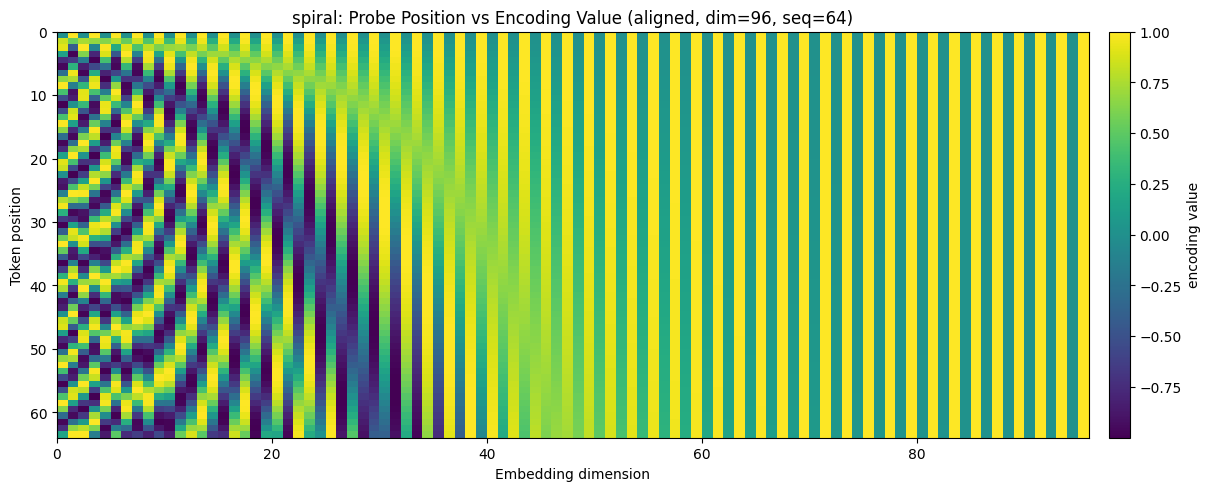

monster shared range (suppressed vs unsuppressed): [-2.240401, 2.453446]


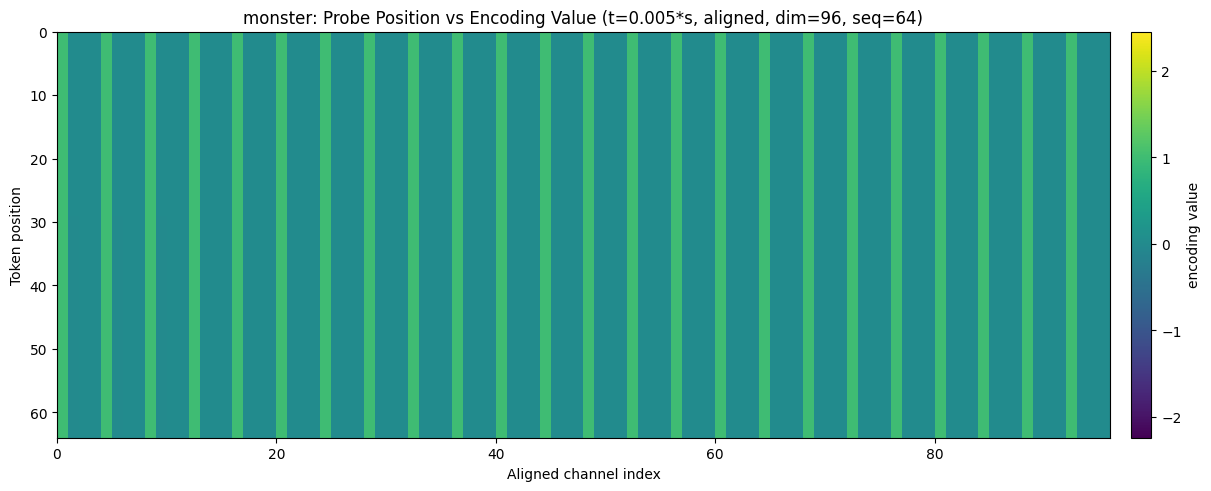

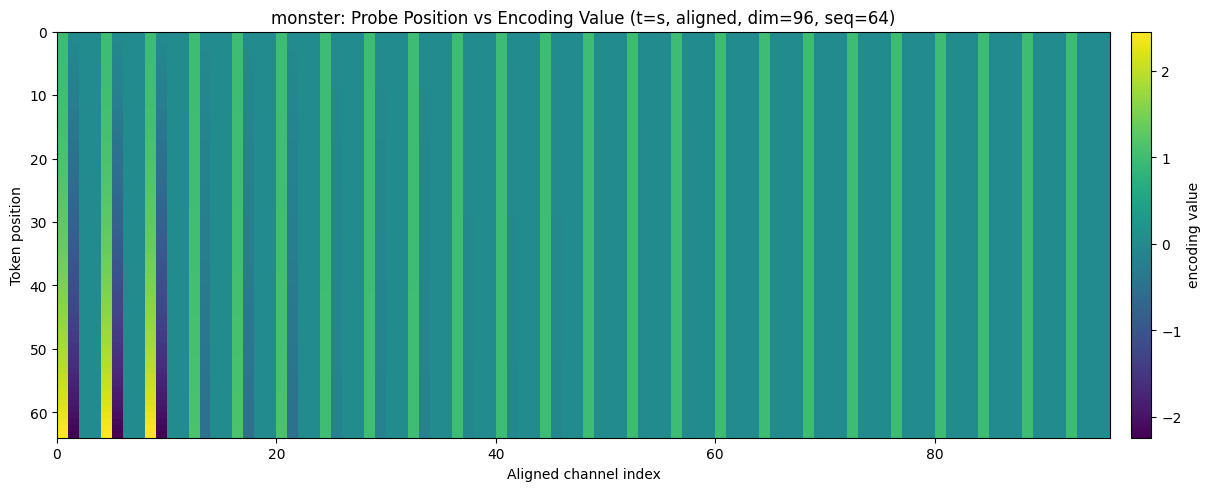

f-monster shared range (suppressed vs unsuppressed): [-2.240401, 2.453446]


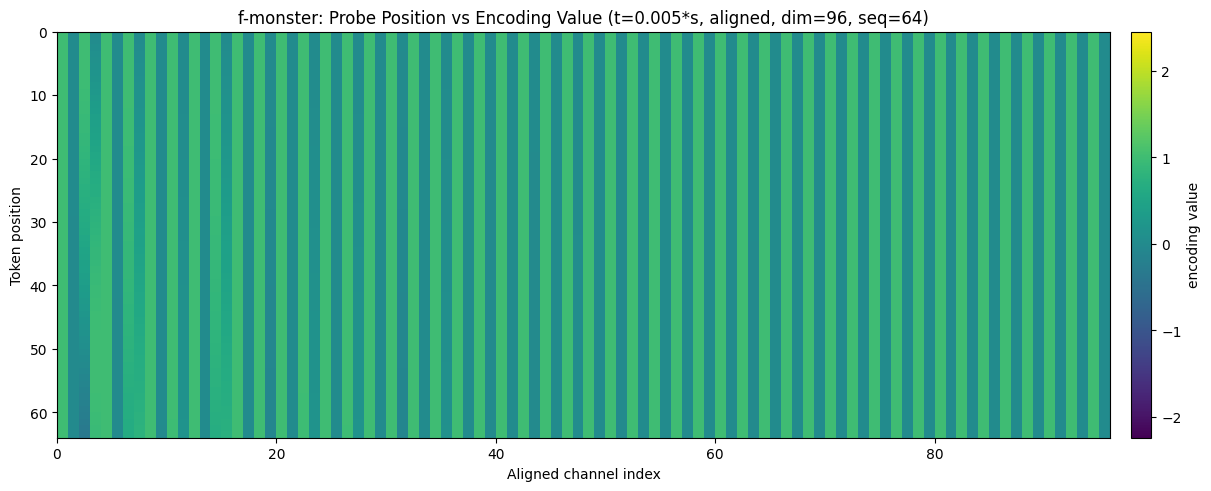

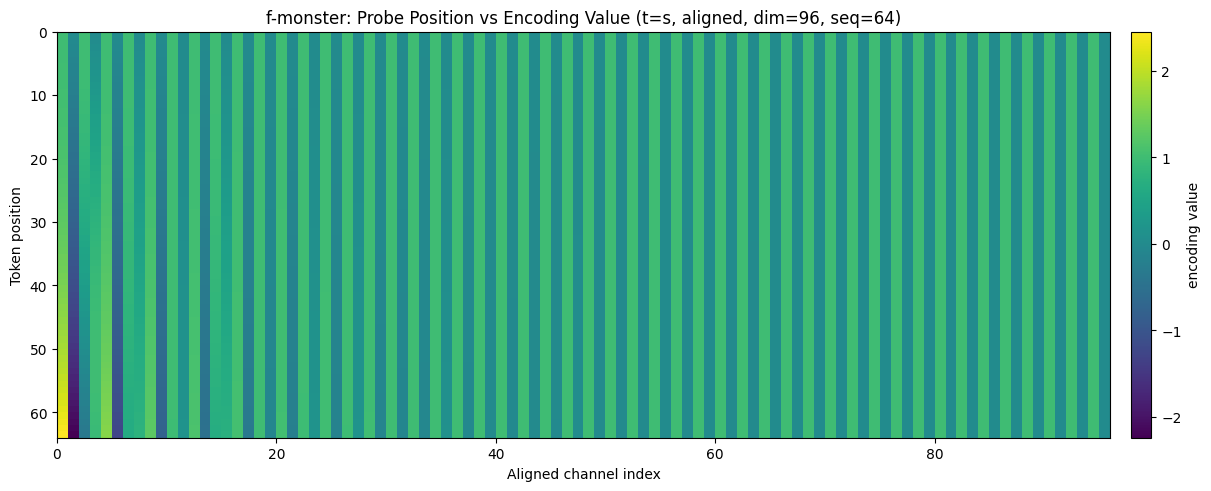

In [168]:
if not probe_contexts:
    print('No compatible encoders for probe positional heatmaps.')
elif not HAVE_MPL:
    print('matplotlib unavailable; skipping probe positional heatmaps.')
else:
    def _orthonormal_bc(axis: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
        b = np.empty_like(axis)
        for k in range(axis.shape[0]):
            a = axis[k]
            ref = np.array([1.0, 0.0, 0.0], dtype=np.float64)
            if abs(a[0]) > 0.9:
                ref = np.array([0.0, 1.0, 0.0], dtype=np.float64)

            vec = ref - np.dot(ref, a) * a
            n = np.linalg.norm(vec)
            if n < 1e-12:
                ref = np.array([0.0, 0.0, 1.0], dtype=np.float64)
                vec = ref - np.dot(ref, a) * a
                n = np.linalg.norm(vec)
            if n < 1e-12:
                raise ValueError('Failed to build orthogonal basis for monster-family alignment.')
            b[k] = vec / n

        c = np.cross(axis, b)
        return b, c

    def build_probe(name: str, cache, dim: int) -> np.ndarray:
        if name == 'f-monster' and hasattr(cache, 'axis'):
            # Axis-aware combined probe: [1, b_f] per block.
            num_freq = cache.axis.shape[0]
            b, _ = _orthonormal_bc(cache.axis)
            probe = np.zeros((1, dim), dtype=np.float64)
            blocks = probe.reshape(1, num_freq, 4)
            blocks[0, :, 0] = 1.0
            blocks[0, :, 1:] = b
            return probe

        if name == 'monster':
            # Boost-focused probe per 4D sub-block: [1,0,0,0].
            probe = np.zeros((1, dim), dtype=np.float64)
            probe[:, 0::4] = 1.0
            return probe

        # RoPE-style pair probe: (1,0) in every 2D pair.
        probe = np.zeros((1, dim), dtype=np.float64)
        probe[:, 0::2] = 1.0
        return probe

    def align_matrix(name: str, raw_mat: np.ndarray, cache) -> np.ndarray:
        # RoPE-family channel alignment to (sin, cos)-style ordering.
        if name in {'rope', 'axial', 'spiral'}:
            aligned = np.empty_like(raw_mat)
            aligned[:, 0::2] = raw_mat[:, 1::2]
            aligned[:, 1::2] = raw_mat[:, 0::2]
            return aligned

        if name == 'f-monster':
            # Project raw spatial channels into block-local (axis, b, c) basis.
            num_freq = cache.axis.shape[0]
            blocks = raw_mat.reshape(DEMO_PROBE_SEQ_LEN, num_freq, 4)
            spatial = blocks[..., 1:]
            b, c = _orthonormal_bc(cache.axis)

            local_t = blocks[..., 0]
            local_axis = np.einsum('pfi,fi->pf', spatial, cache.axis)
            local_b = np.einsum('pfi,fi->pf', spatial, b)
            local_c = np.einsum('pfi,fi->pf', spatial, c)

            # Flatten as [t_local, axis_local, b_local, c_local] per block.
            local = np.stack((local_t, local_axis, local_b, local_c), axis=-1)
            return local.reshape(DEMO_PROBE_SEQ_LEN, -1)

        if name == 'monster':
            # Reorder each triad sub-block to explicit local channels:
            # [t, aligned-axis-component, orth-u, orth-v].
            blocks = raw_mat.reshape(DEMO_PROBE_SEQ_LEN, -1, 3, 4)
            comp_idx = np.array([1, 2, 3], dtype=np.int64)[None, None, :, None]
            pair_idx = np.array([[2, 3], [1, 3], [1, 2]], dtype=np.int64)[None, None, :, :]

            t = blocks[..., 0]
            aligned = np.take_along_axis(blocks, comp_idx, axis=3)[..., 0]
            uv = np.take_along_axis(blocks, pair_idx, axis=3)
            u = uv[..., 0]
            v = uv[..., 1]

            local = np.stack((t, aligned, u, v), axis=-1)
            return local.reshape(DEMO_PROBE_SEQ_LEN, -1)

        return raw_mat

    def monster_bank(time_scale: float) -> PositionBank:
        s = np.arange(DEMO_PROBE_SEQ_LEN, dtype=np.float64)
        t = time_scale * s
        pos4 = np.stack((t, s, s, s), axis=1)
        rope = np.arange(DEMO_PROBE_SEQ_LEN, dtype=np.float64)[:, None]
        return PositionBank(rope_positions=rope, positions_4d=pos4)

    rope_views = {}
    monster_views = {}

    for name in requested_names:
        if name not in probe_contexts:
            continue

        ctx = probe_contexts[name]
        spec = ctx['spec']
        cfg = ctx['cfg']

        if name in {'monster', 'f-monster'}:
            views = {}

            for tag, time_scale in [('suppressed', DEMO_MONSTER_TIME_SCALE), ('unsuppressed', 1.0)]:
                bank = monster_bank(time_scale)
                cache = spec.precompute(cfg, bank)
                probe = build_probe(name, cache, DEMO_DIM)
                out = spec.apply(probe, cache, cfg.position_chunk_size)
                raw_mat = out[0][:DEMO_PROBE_SEQ_LEN, :DEMO_DIM]
                views[tag] = align_matrix(name, raw_mat, cache)

            monster_views[name] = views
        else:
            cache = ctx['cache']
            probe = build_probe(name, cache, DEMO_DIM)
            out = spec.apply(probe, cache, cfg.position_chunk_size)
            raw_mat = out[0][:DEMO_PROBE_SEQ_LEN, :DEMO_DIM]
            rope_views[name] = align_matrix(name, raw_mat, cache)

    print('Probe heatmap setup:')
    print('  monster/f-monster path (suppressed): t=0.005*s, x=y=z=s')
    print('  monster/f-monster path (unsuppressed): t=s, x=y=z=s')
    print('  monster channels are axis-aligned local readouts [t, axis, u, v] per sub-block')
    print('  f-monster channels are axis-aligned local readouts [t, axis, b, c] per block')

    if rope_views:
        rope_min = min(float(np.min(v)) for v in rope_views.values())
        rope_max = max(float(np.max(v)) for v in rope_views.values())
        if abs(rope_max - rope_min) < 1e-12:
            rope_max = rope_min + 1e-12

        print(f'RoPE-family shared range: [{rope_min:.6f}, {rope_max:.6f}]')
        if 'rope' in rope_views:
            pos = np.arange(DEMO_PROBE_SEQ_LEN, dtype=np.float64)[:, None]
            pair_idx = np.arange(0, DEMO_DIM, 2, dtype=np.float64)
            inv_freq = DEMO_THETA_BASE ** (-pair_idx / DEMO_DIM)
            angles = pos * inv_freq[None, :]
            canonical = np.empty((DEMO_PROBE_SEQ_LEN, DEMO_DIM), dtype=np.float64)
            canonical[:, 0::2] = np.sin(angles)
            canonical[:, 1::2] = np.cos(angles)
            corr = np.corrcoef(rope_views['rope'].reshape(-1), canonical.reshape(-1))[0, 1]
            print(f'rope probe sanity corr vs canonical dim={DEMO_DIM}: {corr:.6f}')

        for name in ['rope', 'axial', 'spiral']:
            if name not in rope_views:
                continue
            view = rope_views[name]
            fig, ax = plt.subplots(figsize=(12, 4.8), constrained_layout=True)
            im = ax.pcolormesh(view, cmap='viridis', shading='auto', vmin=rope_min, vmax=rope_max)
            ax.set_title(f'{name}: Probe Position vs Encoding Value (aligned, dim={DEMO_DIM}, seq={DEMO_PROBE_SEQ_LEN})')
            ax.set_xlabel('Embedding dimension')
            ax.set_ylabel('Token position')
            ax.set_xlim((0, DEMO_DIM))
            ax.set_ylim((DEMO_PROBE_SEQ_LEN, 0))
            cbar = fig.colorbar(im, ax=ax, pad=0.02)
            cbar.set_label('encoding value')
            plt.show()

    for name in ['monster', 'f-monster']:
        if name not in monster_views:
            continue
        views = monster_views[name]
        mmin = min(float(np.min(v)) for v in views.values())
        mmax = max(float(np.max(v)) for v in views.values())
        if abs(mmax - mmin) < 1e-12:
            mmax = mmin + 1e-12

        print(f'{name} shared range (suppressed vs unsuppressed): [{mmin:.6f}, {mmax:.6f}]')

        for tag in ['suppressed', 'unsuppressed']:
            view = views[tag]
            label = 't=0.005*s' if tag == 'suppressed' else 't=s'
            fig, ax = plt.subplots(figsize=(12, 4.8), constrained_layout=True)
            im = ax.pcolormesh(view, cmap='viridis', shading='auto', vmin=mmin, vmax=mmax)
            ax.set_title(f'{name}: Probe Position vs Encoding Value ({label}, aligned, dim={DEMO_DIM}, seq={DEMO_PROBE_SEQ_LEN})')
            ax.set_xlabel('Aligned channel index')
            ax.set_ylabel('Token position')
            ax.set_xlim((0, DEMO_DIM))
            ax.set_ylim((DEMO_PROBE_SEQ_LEN, 0))
            cbar = fig.colorbar(im, ax=ax, pad=0.02)
            cbar.set_label('encoding value')
            plt.show()



f-monster local-basis diagnostics:
  boost-only uses t ramp with [1,0,0,0] per block
  rotation-only uses spatial ramp with [0,b_f] per block
  combined uses both ramps with [1,b_f] per block


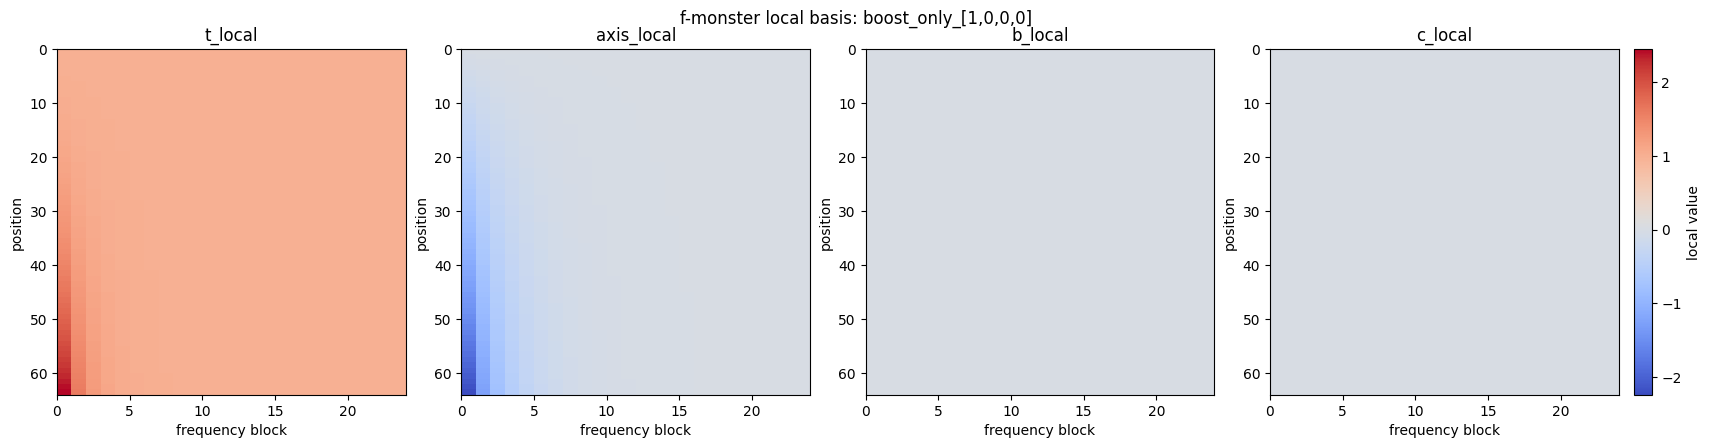

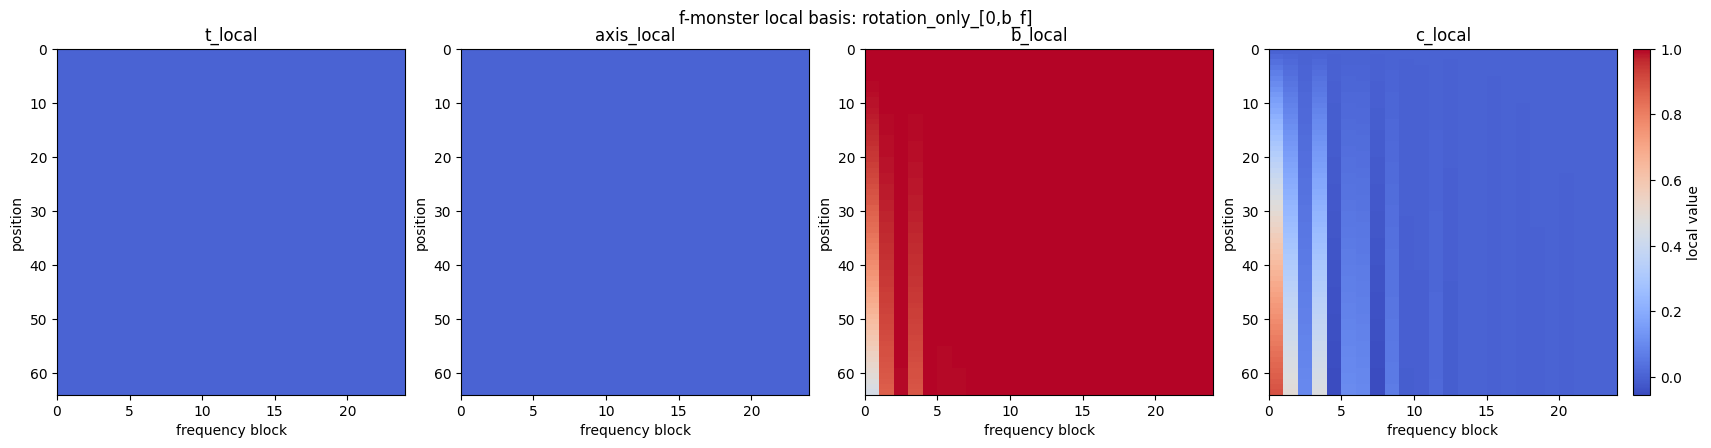

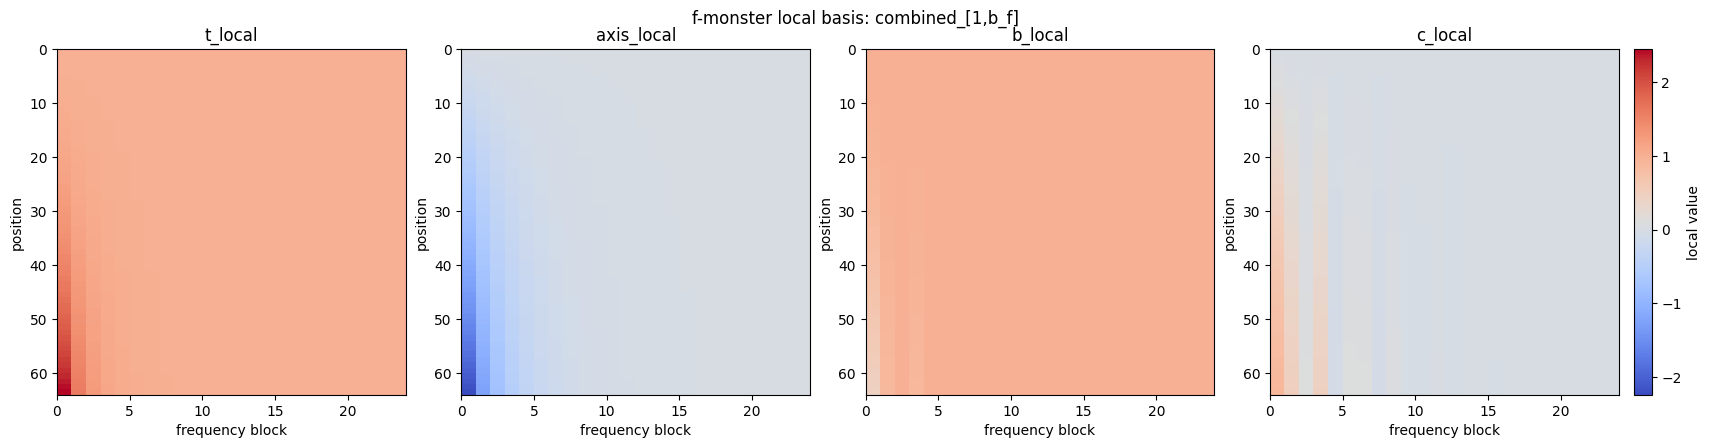

In [169]:
if 'f-monster' not in probe_contexts:
    print('f-monster is not available in probe_contexts; skipping local-basis diagnostics.')
elif not HAVE_MPL:
    print('matplotlib unavailable; skipping f-monster local-basis diagnostics.')
else:
    from core.types import PositionBank

    ctx = probe_contexts['f-monster']
    spec = ctx['spec']
    cfg = ctx['cfg']
    axis = ctx['cache'].axis  # (F,3)
    num_freq = axis.shape[0]

    # Build per-block orthonormal frame (axis, b, c) with b ⟂ axis and c = axis × b.
    b = np.empty_like(axis)
    for k in range(num_freq):
        a = axis[k]
        ref = np.array([1.0, 0.0, 0.0], dtype=np.float64)
        if abs(a[0]) > 0.9:
            ref = np.array([0.0, 1.0, 0.0], dtype=np.float64)

        u = ref - np.dot(ref, a) * a
        n = np.linalg.norm(u)
        if n < 1e-12:
            ref = np.array([0.0, 0.0, 1.0], dtype=np.float64)
            u = ref - np.dot(ref, a) * a
            n = np.linalg.norm(u)
        if n < 1e-12:
            raise ValueError('Failed to build stable f-monster local frame.')
        b[k] = u / n

    c = np.cross(axis, b)

    s = np.arange(DEMO_PROBE_SEQ_LEN, dtype=np.float64)
    # Spatial ramp uses x=y=z=s for interpretability.
    spatial_dir = np.array([1.0, 1.0, 1.0], dtype=np.float64)
    spatial_dir = spatial_dir / np.linalg.norm(spatial_dir)

    def make_bank(t_vals: np.ndarray, spatial_vecs: np.ndarray) -> PositionBank:
        pos4 = np.stack((t_vals, spatial_vecs[:, 0], spatial_vecs[:, 1], spatial_vecs[:, 2]), axis=1)
        rope = np.arange(DEMO_PROBE_SEQ_LEN, dtype=np.float64)[:, None]
        return PositionBank(rope_positions=rope, positions_4d=pos4)

    def project_local(encoded_tensor: np.ndarray) -> np.ndarray:
        blocks = encoded_tensor[0].reshape(DEMO_PROBE_SEQ_LEN, num_freq, 4)
        spatial = blocks[..., 1:]

        local = np.empty_like(blocks)
        local[..., 0] = blocks[..., 0]
        local[..., 1] = np.einsum('pfi,fi->pf', spatial, axis)
        local[..., 2] = np.einsum('pfi,fi->pf', spatial, b)
        local[..., 3] = np.einsum('pfi,fi->pf', spatial, c)
        return local

    diagnostics = {}

    # 1) Boost-only: vary t, keep spatial positions at 0; probe is [1,0,0,0] per block.
    bank_boost = make_bank(t_vals=s, spatial_vecs=np.zeros((DEMO_PROBE_SEQ_LEN, 3), dtype=np.float64))
    cache_boost = spec.precompute(cfg, bank_boost)
    probe_boost = np.zeros((1, DEMO_DIM), dtype=np.float64)
    probe_boost[:, 0::4] = 1.0
    out_boost = spec.apply(probe_boost, cache_boost, cfg.position_chunk_size)
    diagnostics['boost_only_[1,0,0,0]'] = project_local(out_boost)

    # 2) Rotation-only: t=0, vary spatial position along fixed direction; probe is [0,b_f] per block.
    spatial_ramp = s[:, None] * spatial_dir[None, :]
    bank_rot = make_bank(t_vals=np.zeros(DEMO_PROBE_SEQ_LEN, dtype=np.float64), spatial_vecs=spatial_ramp)
    cache_rot = spec.precompute(cfg, bank_rot)
    probe_rot = np.zeros((1, DEMO_DIM), dtype=np.float64)
    probe_rot.reshape(1, num_freq, 4)[0, :, 1:] = b
    out_rot = spec.apply(probe_rot, cache_rot, cfg.position_chunk_size)
    diagnostics['rotation_only_[0,b_f]'] = project_local(out_rot)

    # 3) Combined: vary both t and spatial position; probe is [1,b_f] per block.
    bank_mix = make_bank(t_vals=s, spatial_vecs=spatial_ramp)
    cache_mix = spec.precompute(cfg, bank_mix)
    probe_mix = np.zeros((1, DEMO_DIM), dtype=np.float64)
    blocks_mix = probe_mix.reshape(1, num_freq, 4)
    blocks_mix[0, :, 0] = 1.0
    blocks_mix[0, :, 1:] = b
    out_mix = spec.apply(probe_mix, cache_mix, cfg.position_chunk_size)
    diagnostics['combined_[1,b_f]'] = project_local(out_mix)

    channel_names = ['t_local', 'axis_local', 'b_local', 'c_local']

    print('f-monster local-basis diagnostics:')
    print('  boost-only uses t ramp with [1,0,0,0] per block')
    print('  rotation-only uses spatial ramp with [0,b_f] per block')
    print('  combined uses both ramps with [1,b_f] per block')

    for label, local in diagnostics.items():
        channels = [local[:, :, i] for i in range(4)]
        vmin = min(float(np.min(ch)) for ch in channels)
        vmax = max(float(np.max(ch)) for ch in channels)
        if abs(vmax - vmin) < 1e-12:
            vmax = vmin + 1e-12

        fig, axes = plt.subplots(1, 4, figsize=(17, 4.2), constrained_layout=True)
        im = None
        for i, ax in enumerate(axes):
            im = ax.pcolormesh(channels[i], cmap='coolwarm', shading='auto', vmin=vmin, vmax=vmax)
            ax.set_title(channel_names[i])
            ax.set_xlabel('frequency block')
            ax.set_ylabel('position')
            ax.set_xlim((0, num_freq))
            ax.set_ylim((DEMO_PROBE_SEQ_LEN, 0))

        cbar = fig.colorbar(im, ax=axes, pad=0.01)
        cbar.set_label('local value')
        fig.suptitle(f'f-monster local basis: {label}', y=1.03)
        plt.show()



In [170]:
def offset_curve(sim: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    seq_len = sim.shape[0]
    offsets = np.arange(-(seq_len - 1), seq_len)
    means = np.array([np.mean(np.diag(sim, k=o)) for o in offsets], dtype=np.float64)
    return offsets, means

similarities = {}
similarity_metric = {}
offset_curves = {}
plot_order = []

if not probe_contexts:
    print('No compatible encoders for synthetic q/k attention analysis.')
else:
    from core.positions import build_position_bank, parse_t_values
    from core.types import PositionBank, RunConfig

    rng = np.random.default_rng(0)
    q0 = rng.normal(size=(DEMO_DIM,)).astype(np.float64)
    k0 = rng.normal(size=(DEMO_DIM,)).astype(np.float64)
    base = np.stack((q0, k0), axis=0)

    def make_attn_cfg(base_cfg: RunConfig) -> RunConfig:
        return RunConfig(
            encoders=base_cfg.encoders,
            dim=base_cfg.dim,
            num_vectors=base_cfg.num_vectors,
            seed=base_cfg.seed,
            theta_base=base_cfg.theta_base,
            coords_spec=base_cfg.coords_spec,
            grid_size=base_cfg.grid_size,
            centered_coords=base_cfg.centered_coords,
            t_values=parse_t_values(np.arange(DEMO_ATTN_SEQ_LEN, dtype=np.float64).tolist()),
            z_value=base_cfg.z_value,
            position_chunk_size=DEMO_ATTN_SEQ_LEN,
            save_dir=None,
            save_encoded=False,
            encoder_params=base_cfg.encoder_params,
        )

    def monster_bank(time_scale: float) -> PositionBank:
        s = np.arange(DEMO_ATTN_SEQ_LEN, dtype=np.float64)
        t = time_scale * s
        pos4 = np.stack((t, s, s, s), axis=1)
        rope = np.arange(DEMO_ATTN_SEQ_LEN, dtype=np.float64)[:, None]
        return PositionBank(rope_positions=rope, positions_4d=pos4)

    for name in requested_names:
        if name not in probe_contexts:
            continue

        ctx = probe_contexts[name]
        spec = ctx['spec']
        cfg = make_attn_cfg(ctx['cfg'])

        if name in {'monster', 'f-monster'}:
            for mode, time_scale in [('suppressed', DEMO_MONSTER_TIME_SCALE), ('unsuppressed', 1.0)]:
                cache = spec.precompute(cfg, monster_bank(time_scale))
                out = spec.apply(base, cache, cfg.position_chunk_size)
                q = out[0]
                k = out[1]

                q4 = q.reshape(DEMO_ATTN_SEQ_LEN, -1, 4)
                k4 = k.reshape(DEMO_ATTN_SEQ_LEN, -1, 4)
                eta = np.array([-1.0, 1.0, 1.0, 1.0], dtype=np.float64)
                sim = np.einsum('pfd,d,qfd->pq', q4, eta, k4)

                key = f'{name}:{mode}'
                similarities[key] = sim
                similarity_metric[key] = 'minkowski'
                offset_curves[key] = offset_curve(sim)
                plot_order.append(key)
        else:
            bank = build_position_bank(
                cfg.coords_spec,
                cfg.grid_size,
                cfg.centered_coords,
                cfg.t_values,
                cfg.z_value,
            )
            cache = spec.precompute(cfg, bank)
            out = spec.apply(base, cache, cfg.position_chunk_size)
            q = out[0]
            k = out[1]

            sim = q @ k.T
            key = name
            similarities[key] = sim
            similarity_metric[key] = 'euclidean'
            offset_curves[key] = offset_curve(sim)
            plot_order.append(key)

    print(f'Built synthetic q/k attention analyses (seq={DEMO_ATTN_SEQ_LEN}) for keys:', plot_order)
    print('similarity metric per key:', similarity_metric)



Built synthetic q/k attention analyses for keys: ['rope', 'axial', 'spiral', 'monster:suppressed', 'monster:unsuppressed', 'f-monster:suppressed', 'f-monster:unsuppressed']
similarity metric per key: {'rope': 'euclidean', 'axial': 'euclidean', 'spiral': 'euclidean', 'monster:suppressed': 'minkowski', 'monster:unsuppressed': 'minkowski', 'f-monster:suppressed': 'minkowski', 'f-monster:unsuppressed': 'minkowski'}


rope heatmap range: [-14.964657, +14.964657] (euclidean)


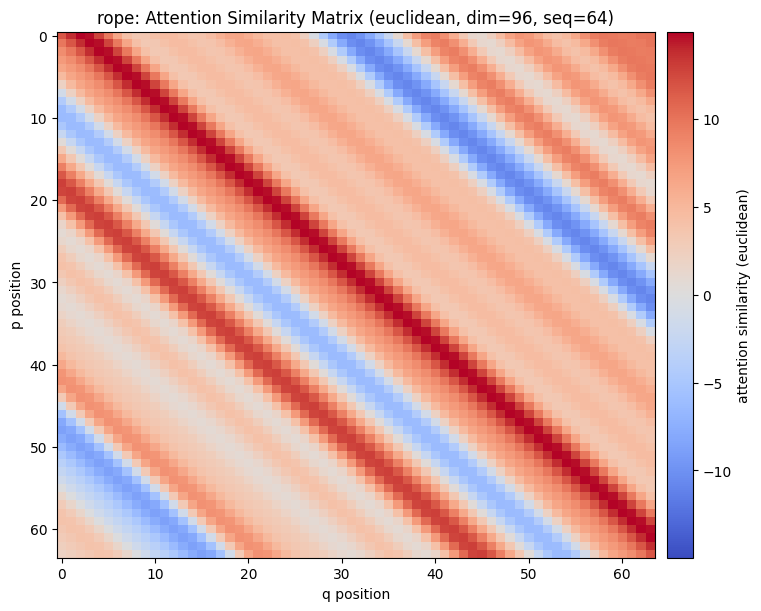

axial heatmap range: [-14.964657, +14.964657] (euclidean)


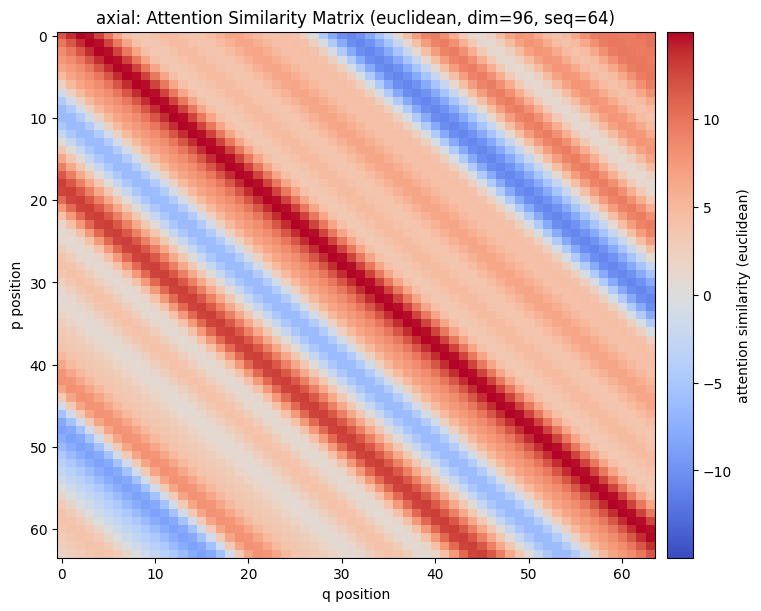

spiral heatmap range: [-14.964657, +14.964657] (euclidean)


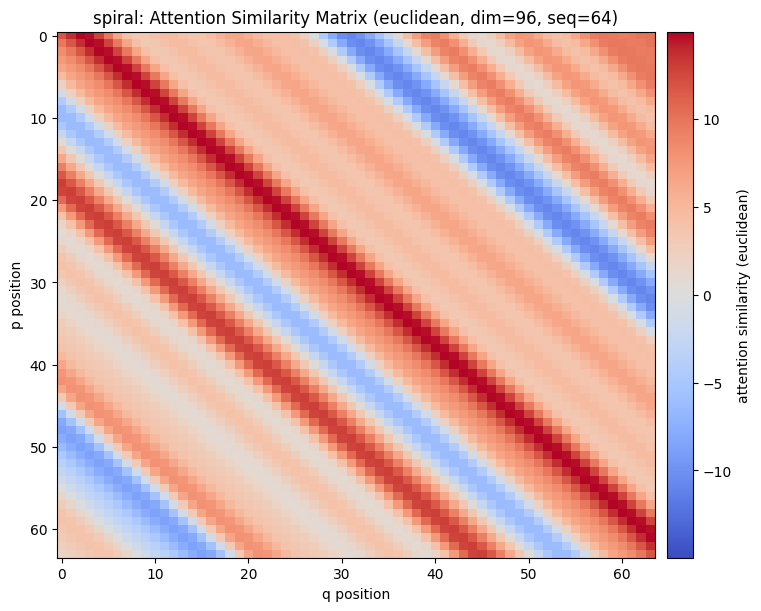

monster:suppressed heatmap range: [-1.644344, +1.644344] (minkowski)


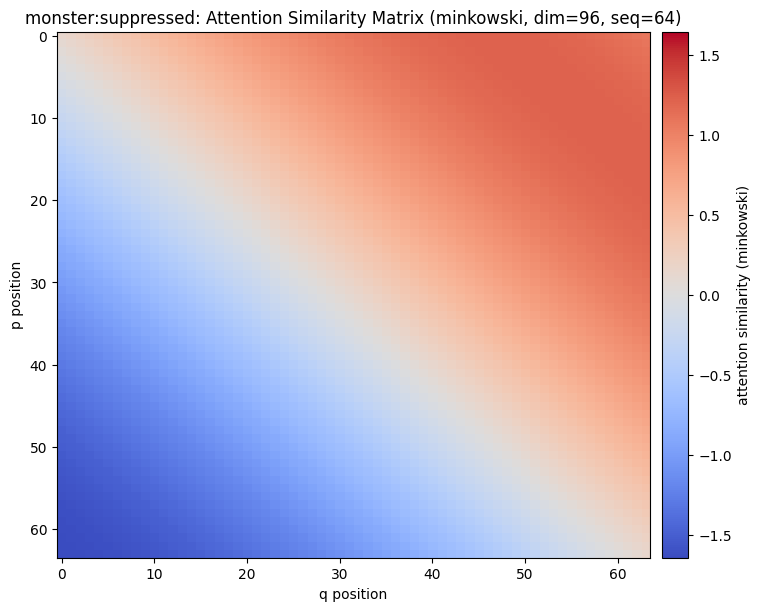

monster:unsuppressed heatmap range: [-2.426489, +2.426489] (minkowski)


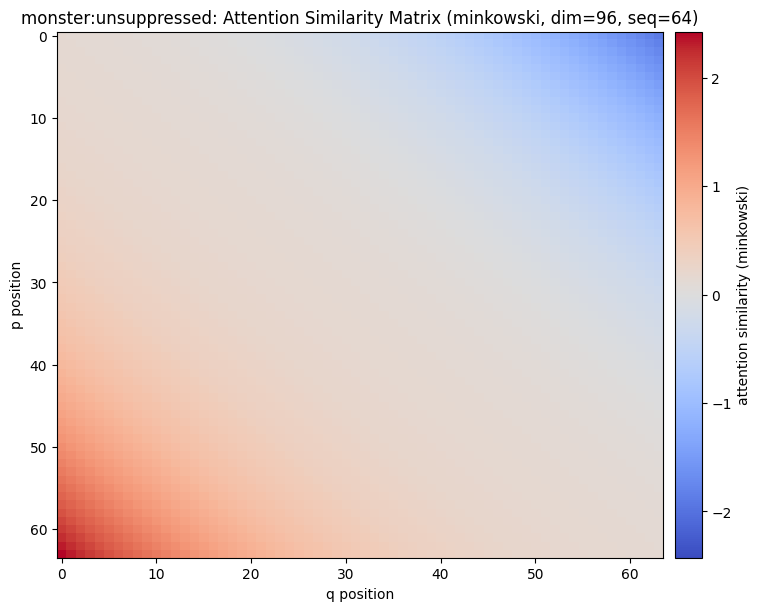

f-monster:suppressed heatmap range: [-0.849955, +0.849955] (minkowski)


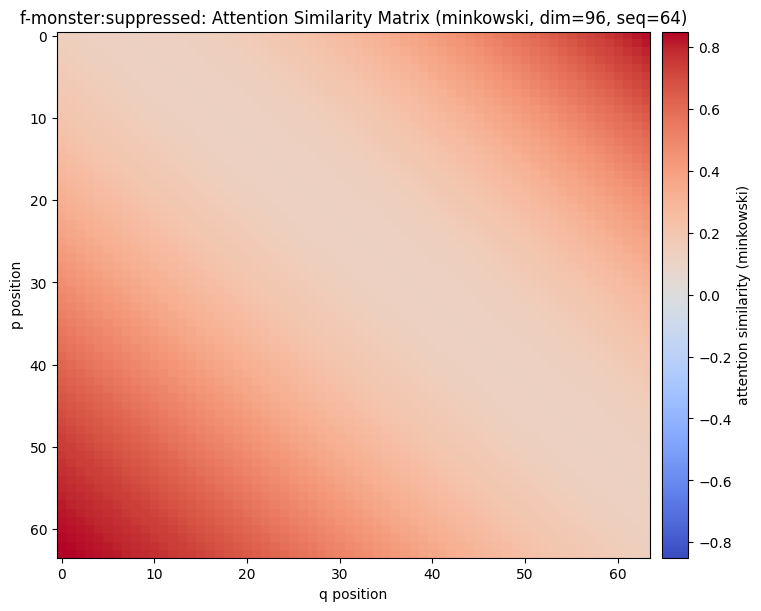

f-monster:unsuppressed heatmap range: [-3.206927, +3.206927] (minkowski)


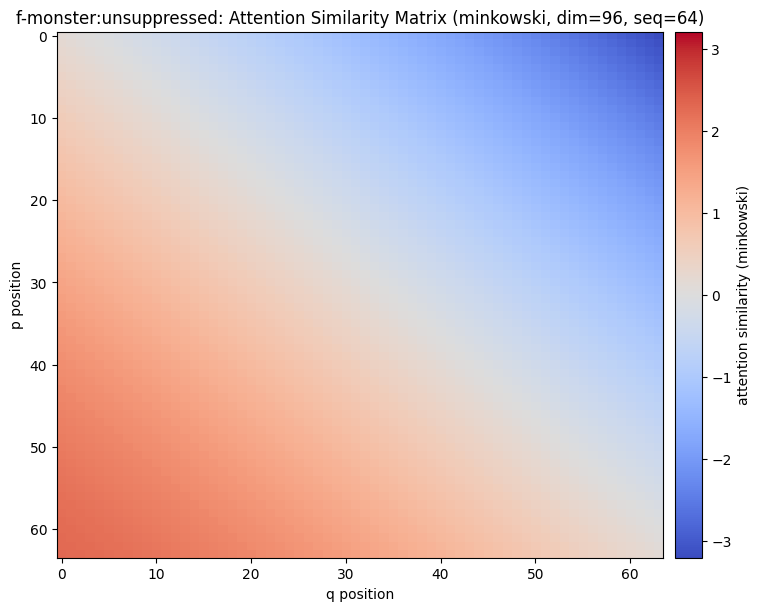

In [171]:
if not similarities:
    print('No similarity matrices to plot.')
elif not HAVE_MPL:
    print('matplotlib unavailable; skipping similarity heatmaps.')
else:
    for key in plot_order:
        sim = similarities[key]
        metric = similarity_metric.get(key, 'euclidean')

        # Per-key symmetric range keeps structure visible for each method/mode.
        local_abs_max = float(np.max(np.abs(sim)))
        if local_abs_max < 1e-12:
            local_abs_max = 1e-12

        print(f'{key} heatmap range: [-{local_abs_max:.6f}, +{local_abs_max:.6f}] ({metric})')

        fig, ax = plt.subplots(figsize=(7.5, 6.0), constrained_layout=True)
        im = ax.imshow(sim, cmap='coolwarm', aspect='auto', vmin=-local_abs_max, vmax=local_abs_max)
        ax.set_title(f'{key}: Attention Similarity Matrix ({metric}, dim={DEMO_DIM}, seq={DEMO_ATTN_SEQ_LEN})')
        ax.set_xlabel('q position')
        ax.set_ylabel('p position')
        cbar = fig.colorbar(im, ax=ax, pad=0.02)
        cbar.set_label(f'attention similarity ({metric})')
        plt.show()



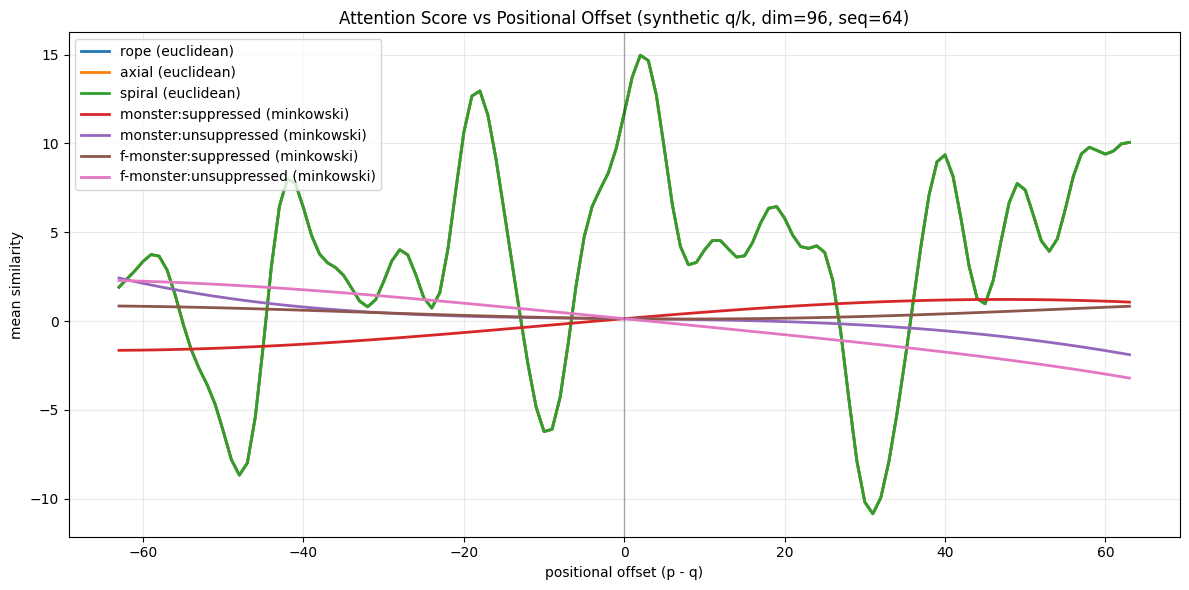

In [172]:
if not offset_curves:
    print('No offset curves to plot.')
elif not HAVE_MPL:
    print('Offset-curve summary (first 5 points per key):')
    for key, (offsets, values) in offset_curves.items():
        head = ', '.join(f'{int(o)}:{v:.3f}' for o, v in zip(offsets[:5], values[:5]))
        print(f'  {key}: {head}')
else:
    plt.figure(figsize=(12, 6))
    for key in plot_order:
        offsets, values = offset_curves[key]
        metric = similarity_metric.get(key, 'euclidean')
        plt.plot(offsets, values, label=f'{key} ({metric})', linewidth=2)

    plt.axvline(0, color='black', linewidth=1, alpha=0.3)
    plt.title(f'Attention Score vs Positional Offset (synthetic q/k, dim={DEMO_DIM}, seq={DEMO_ATTN_SEQ_LEN})')
    plt.xlabel('positional offset (p - q)')
    plt.ylabel('mean similarity')
    plt.grid(alpha=0.25)
    plt.legend()
    plt.tight_layout()
    plt.show()

